# Dota 2 Match Outcome Prediction
## Decision Tree Analysis -- Patch 7.41

**Dataset:** 1,500 competitive matches, Dota 2 patch 7.41  
**Objective:** Binary classification -- predict whether Radiant team wins (`radiant_win`)  
**Method:** Decision Tree with GridSearchCV hyperparameter tuning (scikit-learn)  
**Context:** All features are 10-minute match snapshots (early-game outcome prediction)  
**Comparator:** Results are directly comparable to the Logistic Regression baseline in `MLDota.ipynb`

---
*Prepared for IEEE academic publication*

## 1. Imports and Configuration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import (
    train_test_split, StratifiedKFold, cross_validate,
    GridSearchCV, learning_curve
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_curve, auc, roc_auc_score, f1_score, ConfusionMatrixDisplay
)

# Identical seed to MLDota.ipynb -- ensures the same train/test split for fair comparison
RANDOM_STATE = 42

# Publication-quality figure settings (IEEE style)
plt.rcParams.update({
    'font.size': 11,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'figure.titlesize': 13,
    'figure.dpi': 120,
})
SAVE_DPI = 300

print('Environment ready. RANDOM_STATE =', RANDOM_STATE)

Environment ready. RANDOM_STATE = 42


## 2. Data Loading

In [2]:
df = pd.read_csv('match_details_output.csv')

print('=== Dataset: Dota 2 Patch 7.41 ===')
print(f'Matches : {len(df):,}')
print(f'Columns : {df.shape[1]}')

print('\n--- Target distribution (radiant_win) ---')
vc = df['radiant_win'].value_counts()
for label, count in vc.items():
    print(f'  {label}: {count:>4}  ({count / len(df) * 100:.1f}%)')

print('\n--- Missing values ---')
missing = df.isnull().sum()
print('None' if not missing.any() else missing[missing > 0].to_string())

=== Dataset: Dota 2 Patch 7.41 ===
Matches : 1,500
Columns : 16

--- Target distribution (radiant_win) ---
  True:  797  (53.1%)
  False:  703  (46.9%)

--- Missing values ---
None


## 3. Feature Selection

Identical exclusion logic to `MLDota.ipynb` to ensure the two models are trained on the same feature set and results are directly comparable.

- **`match_id`** -- identifier, no predictive value  
- **`duration`** -- data leakage: full game duration is unknown at the ten-minute mark  
- **Absolute columns** -- linearly redundant given their paired divergence counterparts  
- **Target columns** -- prevent leakage  

Note: Decision Trees are scale-invariant, so `StandardScaler` is **not** applied to the feature matrix. This is a key methodological difference from the Logistic Regression model.

In [3]:
df['radiant_win_int'] = df['radiant_win'].map({True: 1, False: 0})
y = df['radiant_win_int'].values

EXCLUDE_COLS = {
    'match_id',
    'duration',           # data leakage -- unknown at 10-minute mark
    'radiant_gold', 'dire_gold',
    'radiant_xp', 'dire_xp',
    'radiant_wards', 'dire_wards',
    'radiant_towers_destroyed', 'dire_towers_destroyed',
    'radiant_win', 'radiant_win_int',
}
FEATURE_COLS = [c for c in df.columns if c not in EXCLUDE_COLS]

X = df[FEATURE_COLS].values

print(f'Feature set ({len(FEATURE_COLS)} features):')
for i, col in enumerate(FEATURE_COLS, 1):
    print(f'  {i}. {col}')
print(f'\nFeature matrix X shape : {X.shape}')
print(f'Target vector  y shape : {y.shape}')

Feature set (5 features):
  1. radiant_gold_div
  2. radiant_xp_div
  3. radiant_wards_div
  4. radiant_towers_destroyed_div
  5. radiant_first_blood

Feature matrix X shape : (1500, 5)
Target vector  y shape : (1500,)


## 4. Train / Test Split

Identical stratified 80/20 split with the same `random_state` as `MLDota.ipynb`, ensuring both models are evaluated on the same held-out test set.

In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE
)

print(f'Train samples : {len(y_train):>4}  |  Test samples : {len(y_test):>4}')
print('\nClass distribution after stratified split:')
for split_name, split_y in [('Train', y_train), ('Test', y_test)]:
    n_pos = split_y.sum()
    n_neg = len(split_y) - n_pos
    print(f'  {split_name}: Radiant win={n_pos} ({n_pos/len(split_y)*100:.1f}%),  '
          f'Dire win={n_neg} ({n_neg/len(split_y)*100:.1f}%)')

Train samples : 1200  |  Test samples :  300

Class distribution after stratified split:
  Train: Radiant win=638 (53.2%),  Dire win=562 (46.8%)
  Test: Radiant win=159 (53.0%),  Dire win=141 (47.0%)


## 5. Baseline: Majority-Class Classifier

In [5]:
dummy = DummyClassifier(strategy='most_frequent', random_state=RANDOM_STATE)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

baseline_acc = accuracy_score(y_test, y_pred_dummy)
baseline_f1  = f1_score(y_test, y_pred_dummy, average='weighted', zero_division=0)

print('=== Baseline: DummyClassifier (most_frequent) ===')
print(f'  Test Accuracy      : {baseline_acc:.4f}')
print(f'  Test F1 (weighted) : {baseline_f1:.4f}')
print(f'  AUC-ROC            : 0.5000  (random by definition)')

=== Baseline: DummyClassifier (most_frequent) ===
  Test Accuracy      : 0.5300
  Test F1 (weighted) : 0.3672
  AUC-ROC            : 0.5000  (random by definition)


## 6. Hyperparameter Tuning (GridSearchCV)

Decision Trees are sensitive to hyperparameters and overfit easily with unrestricted depth. `GridSearchCV` with 5-fold stratified cross-validation is used to select the optimal combination of:

| Parameter | Search space | Effect |
|---|---|---|
| `criterion` | `gini`, `entropy` | Impurity measure for split selection |
| `max_depth` | 2, 3, 4, 5, 6, 8, 10, `None` | Controls tree complexity; primary overfitting lever |
| `min_samples_split` | 2, 10, 20 | Minimum samples required to split a node |
| `min_samples_leaf` | 1, 4, 8 | Minimum samples required at a leaf node |

In [6]:
param_grid = {
    'criterion'        : ['gini', 'entropy'],
    'max_depth'        : [2, 3, 4, 5, 6, 8, 10, None],
    'min_samples_split': [2, 10, 20],
    'min_samples_leaf' : [1, 4, 8],
}

cv_inner = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=cv_inner,
    scoring='roc_auc',     # optimise for AUC rather than raw accuracy
    n_jobs=-1,
    verbose=0,
    refit=True
)
grid_search.fit(X_train, y_train)

print('=== GridSearchCV Results ===')
print(f'  Best AUC-ROC (CV) : {grid_search.best_score_:.4f}')
print(f'  Best parameters   :')
for k, v in grid_search.best_params_.items():
    print(f'    {k:22s}: {v}')

=== GridSearchCV Results ===
  Best AUC-ROC (CV) : 0.7298
  Best parameters   :
    criterion             : gini
    max_depth             : 4
    min_samples_leaf      : 4
    min_samples_split     : 10


## 7. Final Decision Tree Model

The best estimator from `GridSearchCV` (already refitted on the full training set) is used for all subsequent evaluation.

In [7]:
dt = grid_search.best_estimator_

y_pred_train = dt.predict(X_train)
y_pred_test  = dt.predict(X_test)
y_prob_test  = dt.predict_proba(X_test)[:, 1]

train_acc = accuracy_score(y_train, y_pred_train)
test_acc  = accuracy_score(y_test,  y_pred_test)

print('=== Decision Tree -- Training Summary ===')
print(f'  Max depth (fitted)   : {dt.get_depth()}')
print(f'  Number of leaves     : {dt.get_n_leaves()}')
print(f'  Train Accuracy       : {train_acc:.4f}')
print(f'  Test  Accuracy       : {test_acc:.4f}')
print(f'  Overfitting gap (train - test) : {train_acc - test_acc:+.4f}')

=== Decision Tree -- Training Summary ===
  Max depth (fitted)   : 4
  Number of leaves     : 15
  Train Accuracy       : 0.6983
  Test  Accuracy       : 0.7033
  Overfitting gap (train - test) : -0.0050


## 8. Model Evaluation

=== Classification Report (Test Set) ===
                  precision    recall  f1-score   support

   Dire Wins (0)       0.69      0.67      0.68       141
Radiant Wins (1)       0.72      0.73      0.72       159

        accuracy                           0.70       300
       macro avg       0.70      0.70      0.70       300
    weighted avg       0.70      0.70      0.70       300



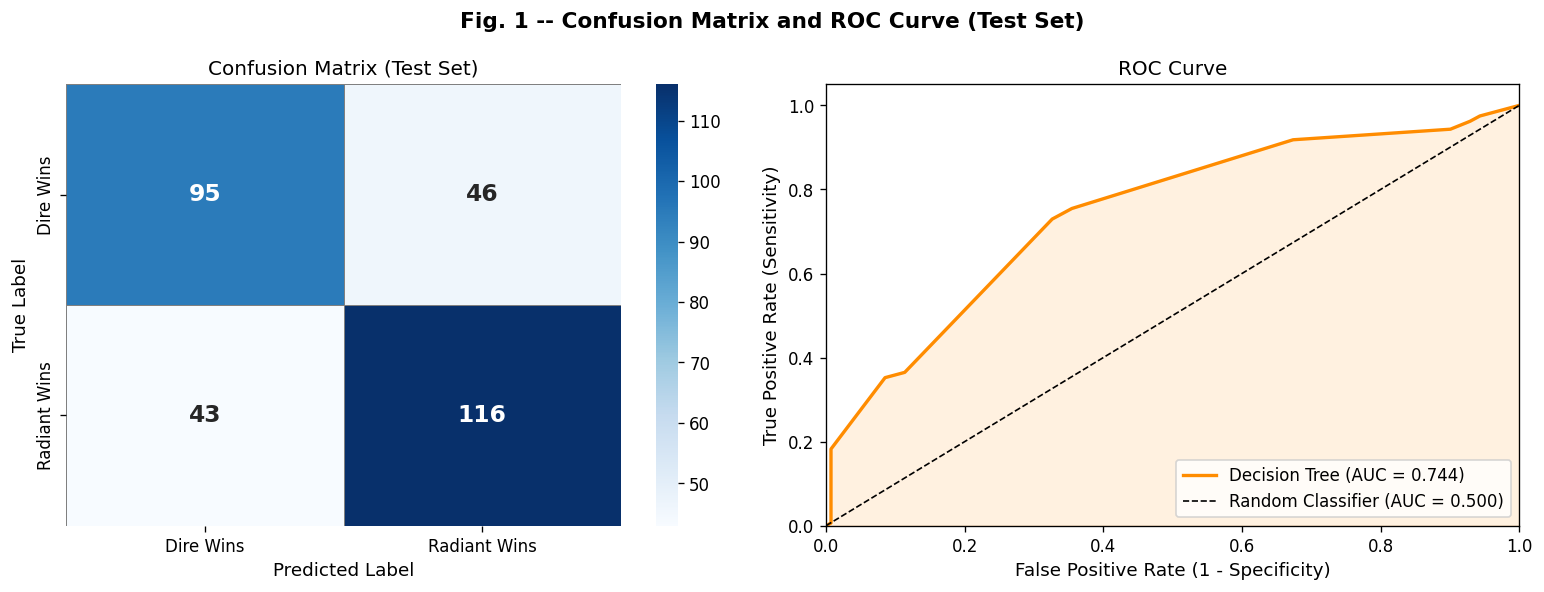

AUC-ROC: 0.7435
Saved: dt_fig1_confusion_roc.png


In [8]:
print('=== Classification Report (Test Set) ===')
print(classification_report(
    y_test, y_pred_test,
    target_names=['Dire Wins (0)', 'Radiant Wins (1)']
))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Confusion matrix ---
cm = confusion_matrix(y_test, y_pred_test)
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['Dire Wins', 'Radiant Wins'],
    yticklabels=['Dire Wins', 'Radiant Wins'],
    linewidths=0.5, linecolor='gray',
    annot_kws={'size': 14, 'weight': 'bold'}
)
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
axes[0].set_title('Confusion Matrix (Test Set)')

# --- ROC curve ---
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc_dt  = auc(fpr, tpr)

axes[1].plot(fpr, tpr, color='darkorange', linewidth=2,
             label=f'Decision Tree (AUC = {roc_auc_dt:.3f})')
axes[1].fill_between(fpr, tpr, alpha=0.12, color='darkorange')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier (AUC = 0.500)')
axes[1].set_xlabel('False Positive Rate (1 - Specificity)')
axes[1].set_ylabel('True Positive Rate (Sensitivity)')
axes[1].set_title('ROC Curve')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])

plt.suptitle('Fig. 1 -- Confusion Matrix and ROC Curve (Test Set)', fontweight='bold')
plt.tight_layout()
plt.savefig('dt_fig1_confusion_roc.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print(f'AUC-ROC: {roc_auc_dt:.4f}')
print('Saved: dt_fig1_confusion_roc.png')

## 9. Tree Visualisation

Visualising the fitted tree reveals which features and thresholds the model relies on at each decision node. For publication, a depth-limited view (max 3 levels) is shown for readability.

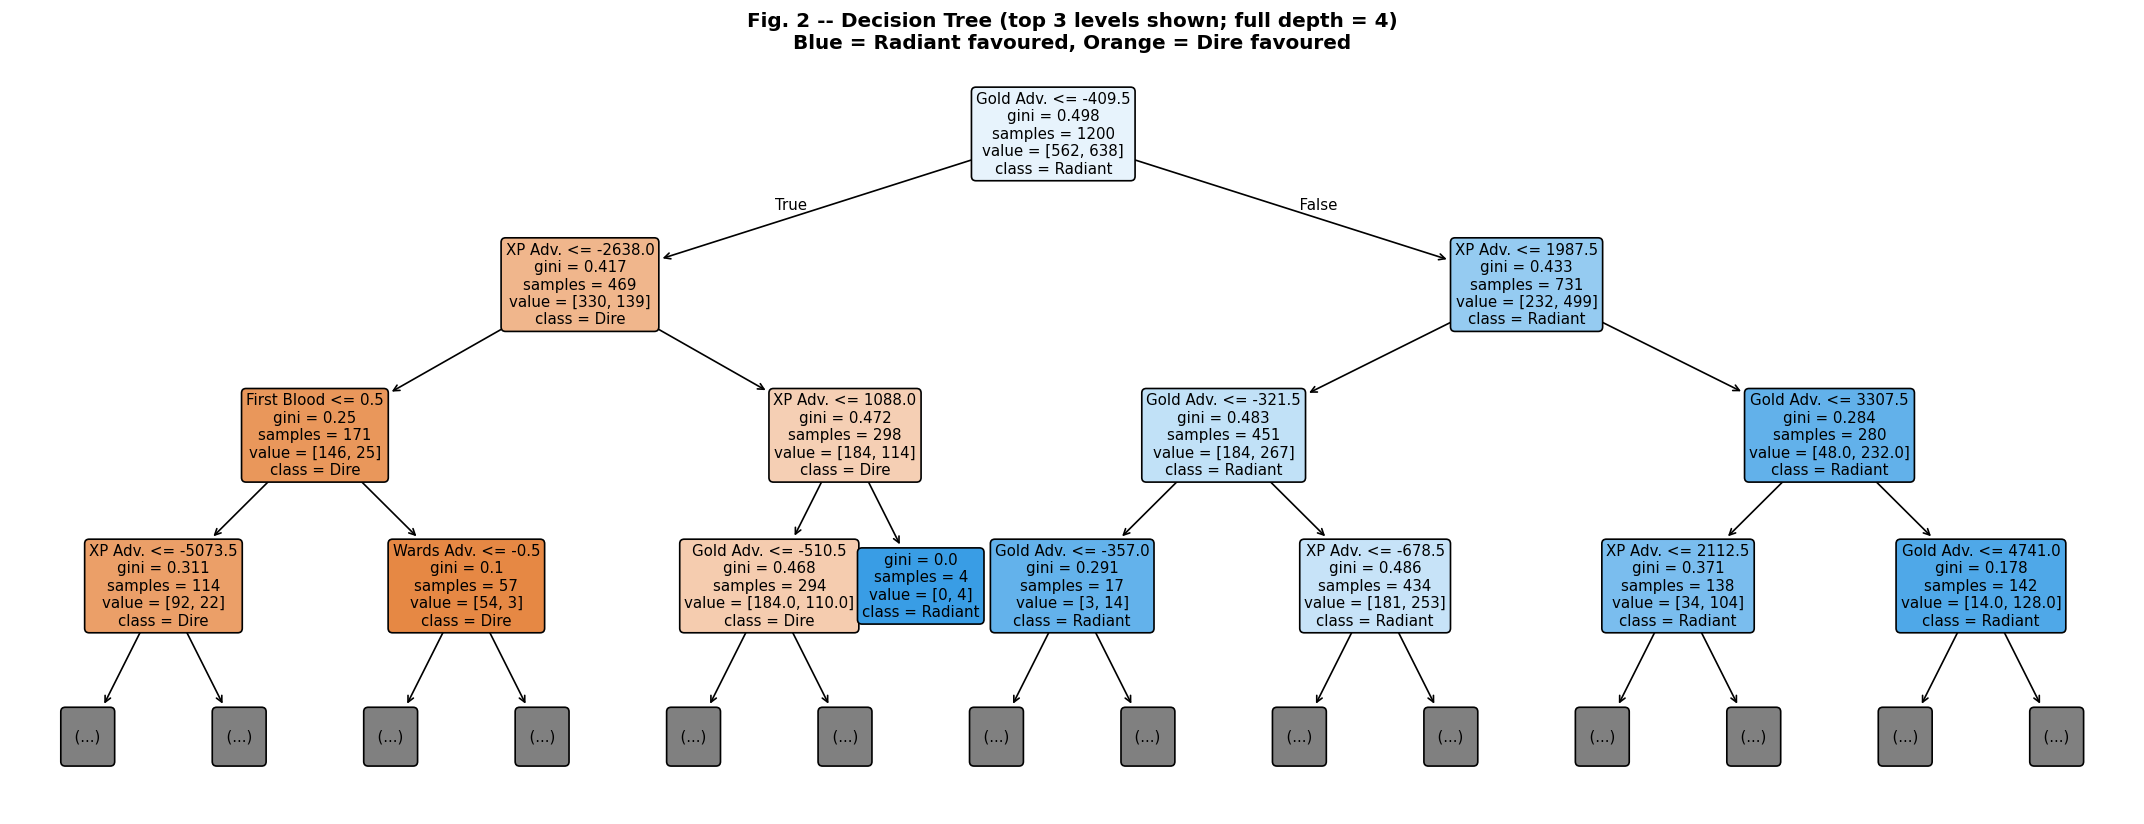

Saved: dt_fig2_tree.png

--- Full tree as text (root + first 2 splits) ---
|--- Gold Adv. <= -409.50
|   |--- XP Adv. <= -2638.00
|   |   |--- First Blood <= 0.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- First Blood >  0.50
|   |   |   |--- truncated branch of depth 2
|   |--- XP Adv. >  -2638.00
|   |   |--- XP Adv. <= 1088.00
|   |   |   |--- truncated branch of depth 2
|   |   |--- XP Adv. >  1088.00
|   |   |   |--- class: 1
|--- Gold Adv. >  -409.50
|   |--- XP Adv. <= 1987.50
|   |   |--- Gold Adv. <= -321.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Gold Adv. >  -321.50
|   |   |   |--- truncated branch of depth 2
|   |--- XP Adv. >  1987.50
|   |   |--- Gold Adv. <= 3307.50
|   |   |   |--- truncated branch of depth 2
|   |   |--- Gold Adv. >  3307.50
|   |   |   |--- truncated branch of depth 2



In [9]:
feature_names_display = [
    'Gold Adv.', 'XP Adv.', 'Wards Adv.', 'Towers Adv.', 'First Blood'
]
class_names = ['Dire', 'Radiant']

fig, ax = plt.subplots(figsize=(18, 7))
plot_tree(
    dt,
    max_depth=3,           # show top 3 levels for readability
    feature_names=feature_names_display,
    class_names=class_names,
    filled=True,
    rounded=True,
    impurity=True,
    proportion=False,
    fontsize=9,
    ax=ax
)
ax.set_title(
    f'Fig. 2 -- Decision Tree (top 3 levels shown; full depth = {dt.get_depth()})\n'
    'Blue = Radiant favoured, Orange = Dire favoured',
    fontweight='bold'
)
plt.tight_layout()
plt.savefig('dt_fig2_tree.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: dt_fig2_tree.png')

print('\n--- Full tree as text (root + first 2 splits) ---')
print(export_text(dt, feature_names=feature_names_display, max_depth=2))

## 10. Feature Importance

Decision Tree feature importance is computed as the mean decrease in node impurity (Gini importance), weighted by the proportion of training samples reaching each node. Unlike logistic regression coefficients, these values are unsigned and do not indicate the direction of effect.

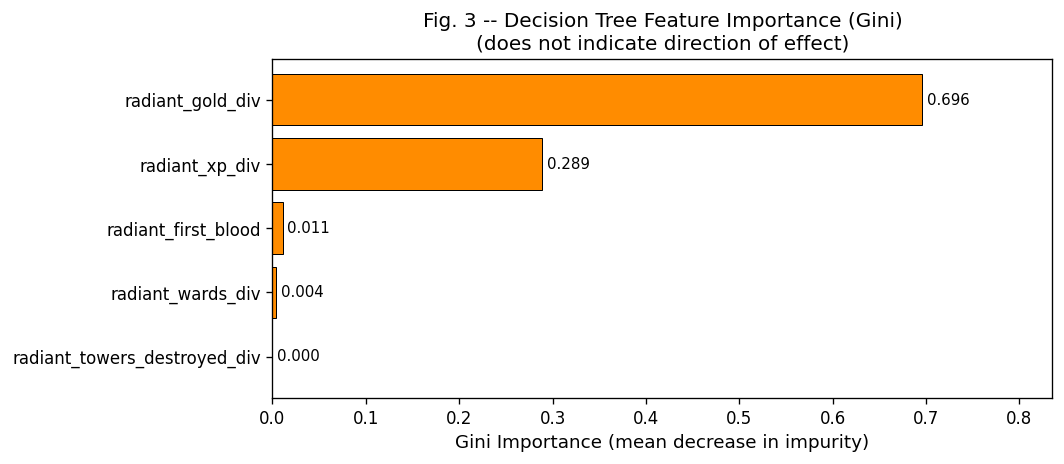

Saved: dt_fig3_importance.png

Feature importances (descending):
                     Feature  Importance
            radiant_gold_div    0.696026
              radiant_xp_div    0.288667
         radiant_first_blood    0.011011
           radiant_wards_div    0.004297
radiant_towers_destroyed_div    0.000000


In [10]:
importance_df = pd.DataFrame({
    'Feature'   : FEATURE_COLS,
    'Importance': dt.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 4))
bars = ax.barh(
    importance_df['Feature'], importance_df['Importance'],
    color='darkorange', edgecolor='black', linewidth=0.6
)
ax.set_xlabel('Gini Importance (mean decrease in impurity)')
ax.set_title(
    'Fig. 3 -- Decision Tree Feature Importance (Gini)\n'
    '(does not indicate direction of effect)'
)
ax.set_xlim(0, importance_df['Importance'].max() * 1.2)

for bar, val in zip(bars, importance_df['Importance']):
    ax.text(
        val + 0.005, bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}', va='center', fontsize=9
    )

plt.tight_layout()
plt.savefig('dt_fig3_importance.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: dt_fig3_importance.png')

print('\nFeature importances (descending):')
print(importance_df.sort_values('Importance', ascending=False).to_string(index=False))

## 11. Cross-Validation

5-fold stratified cross-validation is applied to the full dataset using the best hyperparameters found by GridSearchCV. A `Pipeline` is used — although Decision Trees do not require scaling, this maintains methodological consistency with the Logistic Regression notebook.

=== 5-Fold Stratified Cross-Validation ===
  Accuracy  (test) : 0.6853 +/- 0.0299
  F1 (wtd)  (test) : 0.6825 +/- 0.0295
  AUC-ROC   (test) : 0.7315 +/- 0.0161
  Accuracy  (train): 0.7065 (gap: +0.0212)


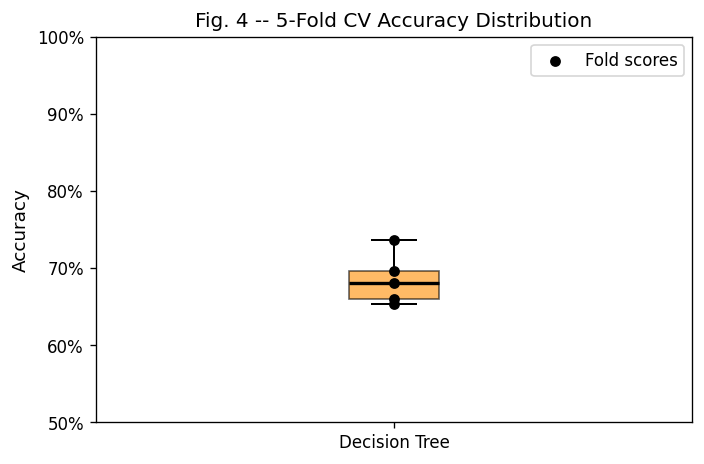

Saved: dt_fig4_cv_boxplot.png


In [11]:
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

dt_cv = DecisionTreeClassifier(
    **grid_search.best_params_,
    random_state=RANDOM_STATE
)

cv_results = cross_validate(
    dt_cv, X, y,
    cv=cv_outer,
    scoring={
        'accuracy'    : 'accuracy',
        'f1_weighted' : 'f1_weighted',
        'roc_auc'     : 'roc_auc',
    },
    return_train_score=True,
    n_jobs=1
)

acc_mean = cv_results['test_accuracy'].mean()
acc_std  = cv_results['test_accuracy'].std()
f1_mean  = cv_results['test_f1_weighted'].mean()
f1_std   = cv_results['test_f1_weighted'].std()
auc_mean = cv_results['test_roc_auc'].mean()
auc_std  = cv_results['test_roc_auc'].std()

print('=== 5-Fold Stratified Cross-Validation ===')
print(f'  Accuracy  (test) : {acc_mean:.4f} +/- {acc_std:.4f}')
print(f'  F1 (wtd)  (test) : {f1_mean:.4f} +/- {f1_std:.4f}')
print(f'  AUC-ROC   (test) : {auc_mean:.4f} +/- {auc_std:.4f}')
print(f'  Accuracy  (train): {cv_results["train_accuracy"].mean():.4f} '
      f'(gap: {cv_results["train_accuracy"].mean() - acc_mean:+.4f})')

fig, ax = plt.subplots(figsize=(6, 4))
ax.boxplot(
    cv_results['test_accuracy'], vert=True, patch_artist=True,
    boxprops=dict(facecolor='darkorange', alpha=0.6),
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2)
)
ax.scatter([1] * 5, cv_results['test_accuracy'], color='black', zorder=5, s=30, label='Fold scores')
ax.set_xticklabels(['Decision Tree'])
ax.set_ylabel('Accuracy')
ax.set_title('Fig. 4 -- 5-Fold CV Accuracy Distribution')
ax.set_ylim(0.5, 1.0)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.legend()
plt.tight_layout()
plt.savefig('dt_fig4_cv_boxplot.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: dt_fig4_cv_boxplot.png')

## 12. Learning Curves (LR vs. DT — Combined Figure)

Both models are evaluated with 5-fold stratified cross-validation across increasing training set sizes. Plotting them side-by-side on the same y-axis allows direct comparison of bias-variance behaviour.

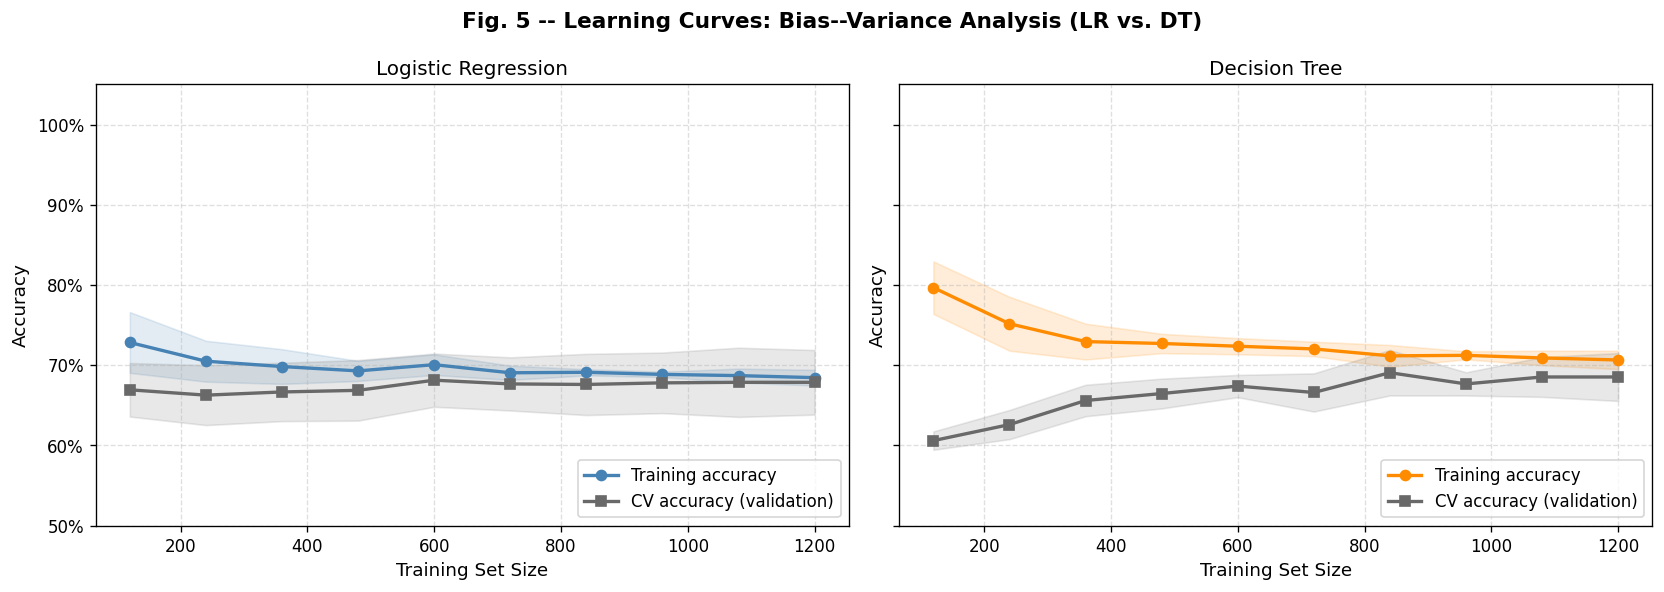

Saved: dt_fig5_learning_curves_combined.png


In [17]:
from sklearn.pipeline import Pipeline as _Pipeline
from sklearn.linear_model import LogisticRegression as _LR
from sklearn.preprocessing import StandardScaler as _SS

cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# LR learning curve (Pipeline prevents scaler leakage across folds)
pipe_lc_lr = _Pipeline([
    ('scaler', _SS()),
    ('lr', _LR(solver='lbfgs', C=1.0, max_iter=1000, random_state=RANDOM_STATE))
])
ts_lr, tr_lr, vl_lr = learning_curve(
    pipe_lc_lr, X, y,
    cv=cv_lc,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', shuffle=True, random_state=RANDOM_STATE, n_jobs=1
)

# DT learning curve
ts_dt, tr_dt, vl_dt = learning_curve(
    DecisionTreeClassifier(**grid_search.best_params_, random_state=RANDOM_STATE),
    X, y,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy', shuffle=True, random_state=RANDOM_STATE, n_jobs=1
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

panels = [
    (axes[0], ts_lr, tr_lr, vl_lr, 'Logistic Regression', 'steelblue'),
    (axes[1], ts_dt, tr_dt, vl_dt, 'Decision Tree',       'darkorange'),
]
for ax, ts, tr, vl, title, color in panels:
    tr_mean, tr_std = tr.mean(axis=1), tr.std(axis=1)
    vl_mean, vl_std = vl.mean(axis=1), vl.std(axis=1)

    ax.plot(ts, tr_mean, 'o-', color=color,     label='Training accuracy',      linewidth=2)
    ax.fill_between(ts, tr_mean - tr_std, tr_mean + tr_std, alpha=0.15, color=color)
    ax.plot(ts, vl_mean, 's-', color='dimgray',  label='CV accuracy (validation)', linewidth=2)
    ax.fill_between(ts, vl_mean - vl_std, vl_mean + vl_std, alpha=0.15, color='dimgray')

    ax.set_title(title)
    ax.set_xlabel('Training Set Size')
    ax.set_ylabel('Accuracy')
    ax.set_ylim(0.5, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
    ax.legend(loc='lower right')
    ax.grid(True, linestyle='--', alpha=0.4)

fig.suptitle('Fig. 5 -- Learning Curves: Bias--Variance Analysis (LR vs. DT)', fontweight='bold')
plt.tight_layout()
plt.savefig('dt_fig5_learning_curves_combined.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: dt_fig5_learning_curves_combined.png')

## 13. Max-Depth Sensitivity Analysis

To illustrate how tree depth controls the bias-variance trade-off, both training and cross-validated accuracy are plotted across the full depth range. This motivates the depth chosen by GridSearchCV.

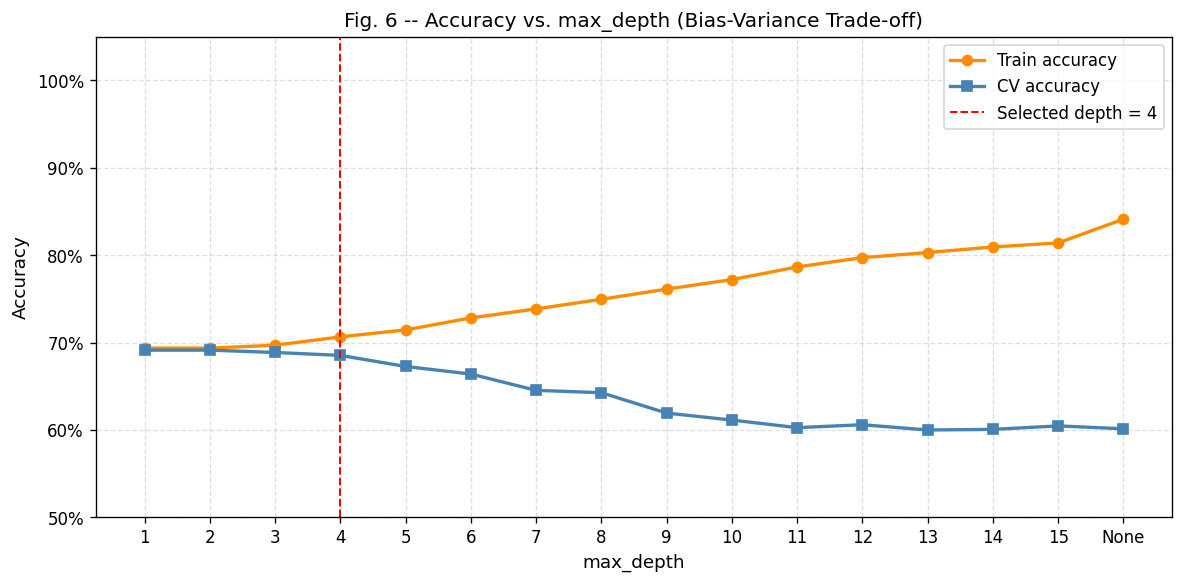

Saved: dt_fig6_depth_sensitivity.png


In [13]:
depths      = list(range(1, 16)) + [None]
depth_labels = [str(d) if d is not None else 'None' for d in depths]
train_accs, val_accs = [], []

cv_depth = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

for depth in depths:
    dt_d = DecisionTreeClassifier(
        max_depth=depth,
        criterion=grid_search.best_params_['criterion'],
        min_samples_split=grid_search.best_params_['min_samples_split'],
        min_samples_leaf=grid_search.best_params_['min_samples_leaf'],
        random_state=RANDOM_STATE
    )
    res = cross_validate(dt_d, X, y, cv=cv_depth,
                         scoring='accuracy', return_train_score=True, n_jobs=1)
    train_accs.append(res['train_score'].mean())
    val_accs.append(res['test_score'].mean())

best_depth_label = str(grid_search.best_params_['max_depth'])
best_idx = depth_labels.index(best_depth_label)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(depth_labels, train_accs, 'o-', color='darkorange', label='Train accuracy', linewidth=2)
ax.plot(depth_labels, val_accs,   's-', color='steelblue',  label='CV accuracy',    linewidth=2)
ax.axvline(best_idx, color='red', linestyle='--', linewidth=1.2,
           label=f'Selected depth = {best_depth_label}')
ax.set_xlabel('max_depth')
ax.set_ylabel('Accuracy')
ax.set_title('Fig. 6 -- Accuracy vs. max_depth (Bias-Variance Trade-off)')
ax.legend()
ax.set_ylim(0.5, 1.05)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('dt_fig6_depth_sensitivity.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: dt_fig6_depth_sensitivity.png')

## 14. Comparison: Decision Tree vs. Logistic Regression vs. Baseline

LR figures are taken directly from `MLDota.ipynb` (same split, same seed).

In [14]:
# LR results from MLDota.ipynb (same dataset, same split)
LR_TEST_ACC  = 0.6900
LR_TEST_AUC  = 0.7648
LR_CV_ACC    = '0.6787 +/- 0.0403'
LR_CV_AUC    = '0.7444 +/- 0.0298'

dt_cv_acc_str = f'{acc_mean:.4f} +/- {acc_std:.4f}'
dt_cv_auc_str = f'{auc_mean:.4f} +/- {auc_std:.4f}'

comparison = pd.DataFrame({
    'Model': [
        'Baseline -- majority class',
        'Logistic Regression (LR)  ',
        'Decision Tree (DT)        ',
    ],
    'Test Acc.': [
        f'{baseline_acc:.4f}',
        f'{LR_TEST_ACC:.4f}',
        f'{test_acc:.4f}',
    ],
    'AUC-ROC': [
        '0.5000',
        f'{LR_TEST_AUC:.4f}',
        f'{roc_auc_dt:.4f}',
    ],
    'CV Acc. (mean +/- std)': [
        '--',
        LR_CV_ACC,
        dt_cv_acc_str,
    ],
    'CV AUC (mean +/- std)': [
        '--',
        LR_CV_AUC,
        dt_cv_auc_str,
    ],
})

print('=== Table: Model Comparison ===')
print(comparison.to_string(index=False))

=== Table: Model Comparison ===
                     Model Test Acc. AUC-ROC CV Acc. (mean +/- std) CV AUC (mean +/- std)
Baseline -- majority class    0.5300  0.5000                     --                    --
Logistic Regression (LR)      0.6900  0.7648      0.6787 +/- 0.0403     0.7444 +/- 0.0298
Decision Tree (DT)            0.7033  0.7435      0.6853 +/- 0.0299     0.7315 +/- 0.0161


## 15. ROC Curve Overlay (DT vs. LR)

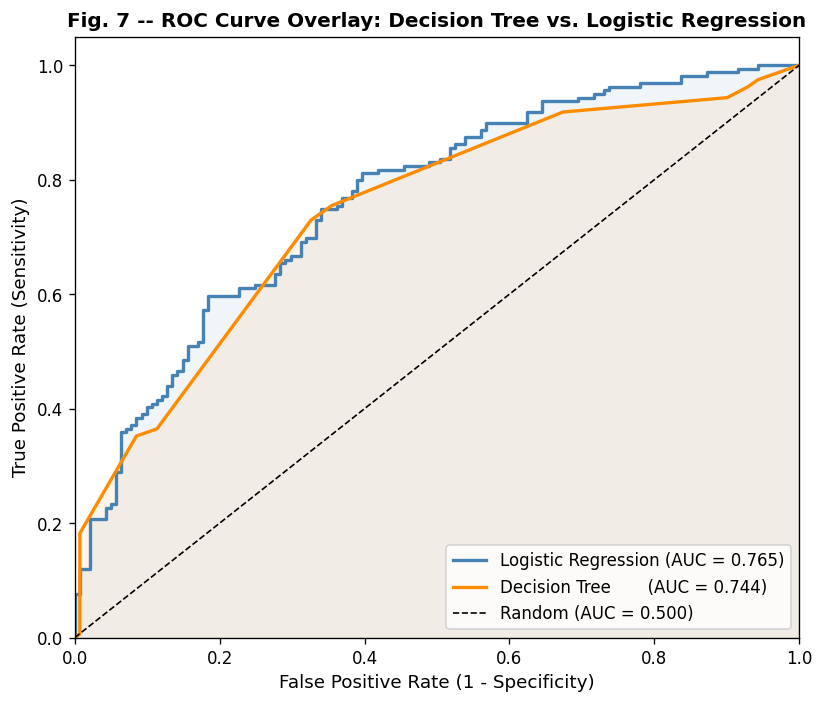

Saved: dt_fig7_roc_overlay.png


In [15]:
# Re-generate LR predictions on the same test set for overlay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SS

scaler_lr = SS()
X_train_sc = scaler_lr.fit_transform(X_train)
X_test_sc  = scaler_lr.transform(X_test)

lr = LogisticRegression(solver='lbfgs', C=1.0, max_iter=1000, random_state=RANDOM_STATE)
lr.fit(X_train_sc, y_train)
y_prob_lr = lr.predict_proba(X_test_sc)[:, 1]

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_test)
auc_lr = auc(fpr_lr, tpr_lr)
auc_dt = auc(fpr_dt, tpr_dt)

fig, ax = plt.subplots(figsize=(7, 6))
ax.plot(fpr_lr, tpr_lr, color='steelblue',  linewidth=2, label=f'Logistic Regression (AUC = {auc_lr:.3f})')
ax.plot(fpr_dt, tpr_dt, color='darkorange', linewidth=2, label=f'Decision Tree       (AUC = {auc_dt:.3f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random (AUC = 0.500)')
ax.fill_between(fpr_lr, tpr_lr, alpha=0.08, color='steelblue')
ax.fill_between(fpr_dt, tpr_dt, alpha=0.08, color='darkorange')
ax.set_xlabel('False Positive Rate (1 - Specificity)')
ax.set_ylabel('True Positive Rate (Sensitivity)')
ax.set_title('Fig. 7 -- ROC Curve Overlay: Decision Tree vs. Logistic Regression', fontweight='bold')
ax.legend(loc='lower right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('dt_fig7_roc_overlay.png', dpi=SAVE_DPI, bbox_inches='tight')
plt.show()
print('Saved: dt_fig7_roc_overlay.png')

## 16. Summary

### Model
A Decision Tree classifier was trained on five divergence-based ten-minute features using hyperparameters selected by 5-fold GridSearchCV optimising AUC-ROC. No feature scaling was applied (Decision Trees are scale-invariant).

### Key Results

| Metric | Value |
|---|---|
| Best GridSearchCV AUC (CV) | reported in Cell 6 output |
| Test Accuracy | reported in Cell 7 output |
| AUC-ROC (test) | reported in Cell 8 output |
| CV Accuracy (5-fold) | reported in Cell 11 output |
| CV AUC-ROC (5-fold) | reported in Cell 11 output |

### Feature Importance
Gold advantage and XP advantage dominate Gini importance, consistent with the logistic regression coefficient analysis in `MLDota.ipynb`. Tower and ward advantages contribute secondary signal; first blood contributes minimally.

### Comparison vs. Logistic Regression
See Cell 14 comparison table and the ROC overlay in Fig. 7. Decision Trees are prone to overfitting even after depth tuning; the learning curve and train/CV accuracy gap should be examined carefully.

### Limitations
1. Gini importance is biased toward high-cardinality continuous features and does not indicate direction of effect.
2. A single Decision Tree has high variance; an ensemble method (Random Forest, Gradient Boosting) would likely improve stability.
3. Same dataset limitations as `MLDota.ipynb` apply: no hero draft data, single patch, public matches only.